In [1]:
import pandas as pd
import h5py 
import numpy as np 
from matplotlib import pyplot as plt 

In [2]:
DATA = '/home/exacloud/gscratch/mcweeney_lab/evans/data' 

In [3]:
siginfo = pd.read_csv(f'{DATA}/siginfo_beta.txt', sep='\t', low_memory=False) 
siginfo.head() 

,bead_batch,nearest_dose,pert_dose,pert_dose_unit,pert_idose,pert_itime,pert_time,pert_time_unit,cell_mfc_name,pert_mfc_id,...,cell_iname,det_wells,det_plates,distil_ids,build_name,project_code,cmap_name,is_exemplar_sig,is_ncs_sig,is_null_sig
0,b17,NaN,100.0,ug/ml,100 ug/ml,336 h,336.0,h,N8,BRD-U44432129,...,NAMEC8,H05|H06|H07|H08,MET001_N8_XH_X1_B17,MET001_N8_XH_X1_B17:H05|MET001_N8_XH_X1_B17:H0...,NaN,MET,BRD-U44432129,0,0.0,0.0
1,b15,10.0,10.0,uM,10 uM,3 h,3.0,h,A549,BRD-K81418486,...,A549,L04|L08|L12,ABY001_A549_XH_X1_B15,ABY001_A549_XH_X1_B15:L04|ABY001_A549_XH_X1_B1...,NaN,ABY,vorinostat,0,1.0,0.0
2,b15,2.5,2.5,uM,2.5 uM,24 h,24.0,h,HT29,BRD-K70511574,...,HT29,E18|E22,ABY001_HT29_XH_X1_B15,ABY001_HT29_XH_X1_B15:E18|ABY001_HT29_XH_X1_B1...,NaN,ABY,HMN-214,0,1.0,0.0
3,b18,10.0,10.0,uM,10 uM,3 h,3.0,h,HME1,BRD-K81418486,...,HME1,F19,LTC002_HME1_3H_X1_B18,LTC002_HME1_3H_X1_B18:F19,NaN,LTC,vorinostat,0,0.0,0.0
4,b15,10.0,10.0,uM,10 uM,3 h,3.0,h,H1975,BRD-A61304759,...,H1975,P01|P05|P09,ABY001_H1975_XH_X1_B15,ABY001_H1975_XH_X1_B15:P01|ABY001_H1975_XH_X1_...,NaN,ABY,tanespimycin,0,0.0,0.0


In [4]:
repls = siginfo[['cell_iname','pert_id', 'pert_dose', 'pert_time', 'sig_id']]
repls = repls.groupby(['cell_iname','pert_id', 'pert_dose', 'pert_time']).agg({'sig_id': lambda x: list(x)}).reset_index() 
repls = repls.assign(n_repl = [len(x) for x in repls.sig_id]) 

# only evaluate for conditions with 2 replicates 
repls = repls[lambda x: x.n_repl == 2] 

repls.head() 

,cell_iname,pert_id,pert_dose,pert_time,sig_id,n_repl
408,22RV1,BRD-A12230535,10.0,24.0,"[ASG002_22RV1_24H:C13, MOAR009_22RV1_24H:C10]",2
1104,22RV1,BRD-K20285085,10.0,24.0,"[ASG002_22RV1_24H:H13, MOAR011_22RV1_24H:F19]",2
1645,22RV1,BRD-K51544265,10.0,24.0,"[DTAK001_22RV1_24H:BRD-K51544265:10, ASG002_22...",2
1870,22RV1,BRD-K62858456,10.0,24.0,"[ASG002_22RV1_24H:F07, MOAR011_22RV1_24H:E19]",2
2551,A204,BRD-A12230535,10.0,24.0,"[ASG002_A204_24H:C13, MOAR009_A204_24H:C10]",2


In [5]:
geneinfo = pd.read_csv(f'{DATA}/geneinfo_beta.txt', sep='\t', low_memory=False)[lambda x: x.feature_space == 'landmark']
landmark_genes = set(geneinfo.gene_id.values.tolist()) 
print('len landmark genes: ', len(landmark_genes)) 
geneinfo.head() 

len landmark genes:  978


,gene_id,gene_symbol,ensembl_id,gene_title,gene_type,src,feature_space
2154,16,AARS,ENSG00000090861,alanyl-tRNA synthetase,protein-coding,NCBI,landmark
2155,23,ABCF1,ENSG00000204574,ATP binding cassette subfamily F member 1,protein-coding,NCBI,landmark
2156,25,ABL1,ENSG00000097007,"ABL proto-oncogene 1, non-receptor tyrosine ki...",protein-coding,NCBI,landmark
2157,30,ACAA1,ENSG00000060971,acetyl-CoA acyltransferase 1,protein-coding,NCBI,landmark
2158,39,ACAT2,ENSG00000120437,acetyl-CoA acetyltransferase 2,protein-coding,NCBI,landmark


In [6]:
hdf = h5py.File(f'{DATA}/level5_beta_trt_cp_n720216x12328.gctx', 'r') 

In [19]:
hdf_sig_ids = hdf['0']['META']['COL']['id'][...].astype(str)
hdf_gene_ids = hdf['0']['META']['ROW']['id'][...].astype(str) 
sig2idx = {s:i for i,s in enumerate(hdf_sig_ids)} 
gene2idx = {g:i for i,g in enumerate(hdf_gene_ids)} 
landmark_mask = np.array([int(g) in landmark_genes for g in hdf_gene_ids]) 
assert (landmark_mask.sum() == len(landmark_genes)), 'landmark_mask is not correct' 

mat = hdf['0']['DATA']['0']['matrix']

In [20]:
rs = [] 
n_fail = 0 
for i,row in repls.reset_index().iterrows(): 
    print(f'progress: {i}/{len(repls)}', end='\r')

    try: 

        x1 = mat[sig2idx[row.sig_id[0]], ...].reshape(-1)[landmark_mask] 
        x2 = mat[sig2idx[row.sig_id[1]], ...].reshape(-1)[landmark_mask] 

        r = np.corrcoef(x1, x2)[0,1] 
        rs.append(r) 

    except: 
        n_fail += 1 

print() 
print('mean r: ', np.mean(rs)) 
print('n_fail: ', n_fail) 


progress: 32895/32896
mean r:  0.2050160001354133
n_fail:  761


In [22]:
len(rs)

32135

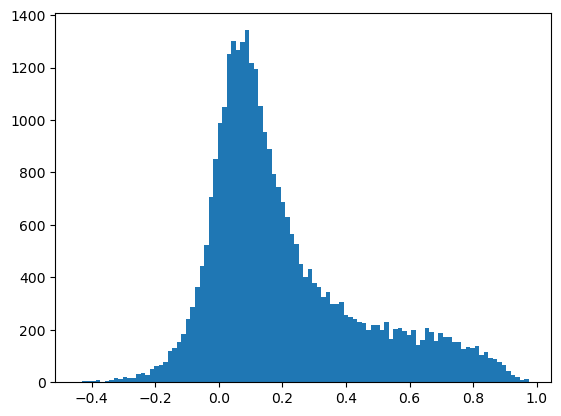

In [21]:
plt.figure() 
plt.hist(rs, bins=100) 
plt.show() 
